# Megan Randow's "Original Project" Based on Dr. Case's Notebook
# Applied Analytics (EDA)

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Megan Randow](https://github.com/sum-randow/)
- Repository: [datafun-06-applied](https://github.com/sum-randow/datafun-06-applied/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06

## Instructions

- Scan the headings first, to get an idea of the process and overall goal. 
- The provided content is a well-structured example that shows the process.
- Seek to understand the process and presentation of the work. 
- The goal is to be able to perform EDA **on any data you choose**. 
- Clean up your copy of this notebook as you work - remove lines indicating the cell type, etc.

## Dataset Information (Custom Project)

- Dataset: NYC Yellow Taxi Trip Data (2020)
- A subset covering two single days — January 11, 2020 (pre-COVID) and
  April 11, 2020 (during COVID lockdown) — used to explore the impact
  of COVID-19 on NYC taxi activity.
- Source: <https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page>
- Data Portal: <https://data.cityofnewyork.us/Transportation/2020-Yellow-Taxi-Trip-Data/kxp8-n2sj>
- Raw file (~200,000 rows, excluded from GitHub via `.gitignore` due to size):
  `data/raw/yellow_taxi_2020_jan11_apr11_raw.csv`
- A smaller random sample of this data is used in the notebook and
  committed to the repository for reproducibility.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

In [18]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("P06-NB", level="DEBUG")
log_header(LOG, "P06-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "yellow_taxi_2020_jan11_apr11_raw"

# ==========================================================
# ANALYST CHOICE:
# Open the dataset in a spreadsheet or notebook and
# decide which columns to use for grouping and numeric analysis.
# ==========================================================

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)

GROUP_COL: Final[str] = "period"

# CUSTOM: Numeric columns to analyze (chose 4-5 numeric variables)

SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "trip_distance",
    "fare_amount",
    "passenger_count",
    "tip_amount",
]

# CUSTOM: Choose one numeric column for a manual statistics example.

EXAMPLE_NUMERIC_COL: Final[str] = "fare_amount"

# CUSTOM: Choose a few numeric columns to check for correlations and plot.
# Look for strong correlations in the descriptive stats section to guide this choice.
# For example, if trip_distance and fare_amount show strong correlation, plot those

SCATTER_X_COL: Final[str] = "trip_distance"
SCATTER_Y_COL: Final[str] = "fare_amount"

BOX_Y_COL: Final[str] = "tip_amount"

# CUSTOM: Assign readable labels for the charted variables.

SCATTER_X_LABEL: Final[str] = "Trip Distance (miles)"
SCATTER_Y_LABEL: Final[str] = "Fare Amount ($)"

BOX_Y_LABEL: Final[str] = "Tip Amount ($)"

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-19 17:14:14 | INFO | P06-NB | === RUN START ===
2026-06-19 17:14:14 | INFO | P06-NB | project=P06-NB
2026-06-19 17:14:14 | INFO | P06-NB | repo_dir=datafun-06-applied
2026-06-19 17:14:14 | INFO | P06-NB | python=3.14.6
2026-06-19 17:14:14 | INFO | P06-NB | os=Darwin 25.5.0
2026-06-19 17:14:14 | INFO | P06-NB | shell=zsh
2026-06-19 17:14:14 | INFO | P06-NB | cwd=notebooks
2026-06-19 17:14:14 | INFO | P06-NB | github_actions=False
2026-06-19 17:14:14 | INFO | P06-NB | Imports complete.


## Section 2. Load the Data

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

In [19]:
# Python cell

# Load a dataset into a DataFrame.

# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(f"../data/raw/{DATASET_NAME}.csv")
count_of_rows: int = df.shape[0]
count_of_columns: int = df.shape[1]
LOG.info(f"Loaded: {count_of_rows} rows, {count_of_columns} columns")

# Create a 'period' column based on pickup date
df["pickup_date"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.date
df["period"] = df["pickup_date"].apply(
    lambda d: "Jan 2020" if d.month == 1 else "Apr 2020"
)

# Take a random sample to keep the dataset small enough for GitHub
SAMPLE_SIZE: Final[int] = 15000
df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Recompute row/column counts after sampling
count_of_rows: int = df.shape[0]
count_of_columns: int = df.shape[1]
LOG.info(f"After sampling: {count_of_rows} rows, {count_of_columns} columns")

# Save the sampled dataset so it can be committed to the repo
df.to_csv(f"../data/raw/{DATASET_NAME}_sample.csv", index=False)
LOG.info(f"Saved sampled dataset to data/raw/{DATASET_NAME}_sample.csv")

2026-06-19 17:14:14 | INFO | P06-NB | Loading dataset: yellow_taxi_2020_jan11_apr11_raw
2026-06-19 17:14:14 | INFO | P06-NB | Loaded: 225015 rows, 18 columns
2026-06-19 17:14:15 | INFO | P06-NB | After sampling: 15000 rows, 20 columns
2026-06-19 17:14:15 | INFO | P06-NB | Saved sampled dataset to data/raw/yellow_taxi_2020_jan11_apr11_raw_sample.csv


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

In [20]:
# Section 3

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-19 17:14:15 | INFO | P06-NB | Previewing first few rows of the dataset


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,period
0,2.0,2020 Jan 08 04:53:54 PM,2020 Jan 08 05:02:27 PM,1.0,1.68,1.0,N,239,236,1.0,8.0,1.0,0.5,3.08,0.0,0.3,15.38,2.5,2020-01-08,Jan 2020
1,1.0,2020 Jan 08 05:19:49 PM,2020 Jan 08 05:28:22 PM,0.0,0.80,1.0,N,170,186,1.0,7.0,3.5,0.5,2.25,0.0,0.3,13.55,2.5,2020-01-08,Jan 2020
2,2.0,2020 Jan 08 10:32:21 PM,2020 Jan 08 10:43:38 PM,1.0,3.32,1.0,N,170,262,1.0,11.5,0.5,0.5,3.06,0.0,0.3,18.36,2.5,2020-01-08,Jan 2020
3,2.0,2020 Jan 08 11:12:12 PM,2020 Jan 08 11:16:17 PM,1.0,0.49,1.0,N,142,142,2.0,4.0,0.5,0.5,0.00,0.0,0.3,7.80,2.5,2020-01-08,Jan 2020
4,2.0,2020 Jan 08 09:14:24 AM,2020 Jan 08 09:21:41 AM,1.0,0.74,1.0,N,48,230,1.0,6.5,0.0,0.5,1.00,0.0,0.3,10.80,2.5,2020-01-08,Jan 2020


In [21]:
# Section 3

LOG.info("Column names")
column_names: list[str] = list(df.columns)
print(column_names)

2026-06-19 17:14:15 | INFO | P06-NB | Column names


['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'pickup_date', 'period']


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)


In [22]:
# Section 4

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-19 17:14:15 | INFO | P06-NB | Building starter data dictionary
2026-06-19 17:14:15 | DEBUG | P06-NB | 
                   column    dtype  missing_count  missing_pct
0                VendorID  float64            342         2.28
1    tpep_pickup_datetime      str              0         0.00
2   tpep_dropoff_datetime      str              0         0.00
3         passenger_count  float64            342         2.28
4           trip_distance  float64              0         0.00
5              RatecodeID  float64            342         2.28
6      store_and_fwd_flag      str            342         2.28
7            PULocationID    int64              0         0.00
8            DOLocationID    int64              0         0.00
9            payment_type  float64            342         2.28
10            fare_amount  float64              0         0.00
11                  extra  float64              0         0.00
12                mta_tax  float64              0         0.00
13     

In [23]:
# Section 4

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-19 17:14:15 | INFO | P06-NB | Missing values per column:
2026-06-19 17:14:15 | INFO | P06-NB | VendorID                 342
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          342
trip_distance              0
RatecodeID               342
store_and_fwd_flag       342
PULocationID               0
DOLocationID               0
payment_type             342
fare_amount                0
extra                      0
mta_tax                    0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge       0
pickup_date                0
period                     0
dtype: int64
2026-06-19 17:14:15 | INFO | P06-NB | Checking missing values per column
2026-06-19 17:14:15 | DEBUG | P06-NB | 
VendorID                 342
passenger_count          342
RatecodeID               342
store_and_fwd_flag       342
payment_type             342
mta_tax                    0
pickup_date      

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

In [24]:
# Section 5

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-19 17:14:15 | DEBUG | P06-NB | Columns required to be non-missing: ['trip_distance', 'fare_amount', 'passenger_count', 'tip_amount', 'period']
2026-06-19 17:14:15 | INFO | P06-NB | Original rows: 15000
2026-06-19 17:14:15 | INFO | P06-NB | Clean rows:    14658
2026-06-19 17:14:15 | INFO | P06-NB | Rows dropped:  342


Original rows: 15000
Clean rows:    14658
Rows dropped:  342


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

In [25]:
# Section 6

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy

example_values = df_clean[EXAMPLE_NUMERIC_COL]

# Use general variable names so the function can be reused.

mean_value = np.mean(example_values)
std_value = np.std(example_values)
min_value = np.min(example_values)
max_value = np.max(example_values)
range_value = np.ptp(
    example_values
)  # ptp is "peak to peak" = max - min, a measure of spread


# Log the example results with formatting
LOG.debug(f"{EXAMPLE_NUMERIC_COL} Statistics (using numpy):")
LOG.debug(f"  Mean: {mean_value:.2f}")
LOG.debug(f"  Std Dev: {std_value:.2f}")
LOG.debug(f"  Min: {min_value:.2f}")
LOG.debug(f"  Max: {max_value:.2f}")
LOG.debug(f"  Range: {range_value:.2f}")

2026-06-19 17:14:15 | INFO | P06-NB | --------------- Manual statistics ---------------
2026-06-19 17:14:15 | DEBUG | P06-NB | fare_amount Statistics (using numpy):
2026-06-19 17:14:15 | DEBUG | P06-NB |   Mean: 12.11
2026-06-19 17:14:15 | DEBUG | P06-NB |   Std Dev: 12.78
2026-06-19 17:14:15 | DEBUG | P06-NB |   Min: -52.00
2026-06-19 17:14:15 | DEBUG | P06-NB |   Max: 578.50
2026-06-19 17:14:15 | DEBUG | P06-NB |   Range: 630.50


In [26]:
# Section 6

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-19 17:14:15 | INFO | P06-NB | Computing overall descriptive statistics
2026-06-19 17:14:15 | DEBUG | P06-NB | 
                   count       mean        std   min   25%   50%    75%     max
trip_distance    14658.0   2.757234   3.951433   0.0  0.91  1.52   2.70  109.31
fare_amount      14658.0  12.107494  12.780062 -52.0  6.00  8.50  13.00  578.50
passenger_count  14658.0   1.455929   1.112430   0.0  1.00  1.00   1.00    6.00
tip_amount       14658.0   2.177777   2.691170   0.0  0.00  1.96   2.86  117.28
2026-06-19 17:14:15 | INFO | P06-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-19 17:14:15 | INFO | P06-NB | Computing descriptive statistics by group
2026-06-19 17:14:15 | DEBUG | P06-NB | 
         trip_distance                                  fare_amount                                     \
                 count      mean       std  min     max       count       mean        std   min    max   
period                                        

In [27]:
# Section 6

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-19 17:14:15 | INFO | P06-NB | --------------- Improving the output ---------------
2026-06-19 17:14:15 | DEBUG | P06-NB | 
                          count       mean        std   min     max
period                                                             
Apr 2020 trip_distance      495   2.898667   6.145827   0.0  109.31
         fare_amount        495  11.880000  27.951056 -20.0  578.50
         passenger_count    495   1.234343   0.978324   0.0    6.00
         tip_amount         495   1.659596   5.750439   0.0  117.28
Jan 2020 trip_distance    14163   2.752290   3.852441   0.0   66.59
         fare_amount      14163  12.115444  11.907347 -52.0  349.00
         passenger_count  14163   1.463673   1.116060   0.0    6.00
         tip_amount       14163   2.195887   2.516418   0.0   40.69


## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

In [28]:
# Section 7

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns - this will show all of them but it can be too much:
# df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")
df_clean_numeric_cols: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-19 17:14:15 | INFO | P06-NB | Computing correlation matrix for numeric columns
2026-06-19 17:14:15 | INFO | P06-NB | 
Correlation matrix:
2026-06-19 17:14:15 | DEBUG | P06-NB | 
                 trip_distance  fare_amount  passenger_count  tip_amount
trip_distance         1.000000     0.867274         0.020401    0.564737
fare_amount           0.867274     1.000000         0.023083    0.623202
passenger_count       0.020401     0.023083         1.000000    0.005150
tip_amount            0.564737     0.623202         0.005150    1.000000


2026-06-19 17:14:15 | INFO | P06-NB | ---------Visualize Correlation Matrix as a Heatmap---------------
2026-06-19 17:14:15 | INFO | P06-NB | Saved heatmap to docs/images/Figure_5.png


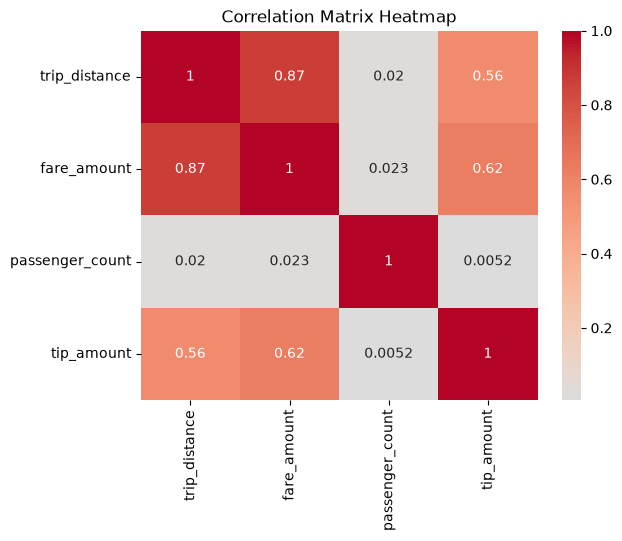

In [29]:
# Section 7

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")

plt.savefig("../docs/images/Figure_5.png", dpi=150, bbox_inches="tight")
LOG.info("Saved heatmap to docs/images/Figure_5.png")

plt.show()

# Interpretation:

- Values close to 1 (dark red) = strong positive correlation (both increase together)
- Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
- Values close to 0 (white) = little or no linear relationship
- The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **trip_distance** and **fare_amount** show a strong positive correlation (~0.87), confirming that longer trips generally cost more. **fare_amount** and **tip_amount** show a moderate positive correlation (~0.62), suggesting tips tend to scale with fare size. **passenger_count** shows almost no correlation with any other variable (~0.02), meaning the number of riders in a cab has little relationship to trip distance, cost, or tipping behavior.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.

2026-06-19 17:14:15 | INFO | P06-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-19 17:14:15 | INFO | P06-NB | ----   Use clean dataframe ---------------------------
2026-06-19 17:14:15 | INFO | P06-NB | ----   Set x to Trip Distance (miles) -----------------------
2026-06-19 17:14:15 | INFO | P06-NB | ----   Set y to Fare Amount ($) --------------------------
2026-06-19 17:14:15 | INFO | P06-NB | ----   Set the hue (color mapping) to the group column --
2026-06-19 17:14:16 | INFO | P06-NB | Saved scatter plot to docs/images/Figure_6.png


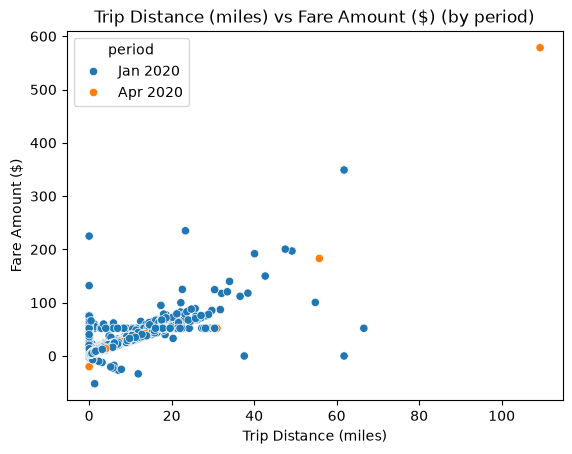

In [30]:
# Section 8 -- use "Run All" so prior cells are executed first.
LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info(f"----   Set x to {SCATTER_X_LABEL} -----------------------")
LOG.info(f"----   Set y to {SCATTER_Y_LABEL} --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x=SCATTER_X_COL,
    y=SCATTER_Y_COL,
    hue=GROUP_COL,
)
# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel(SCATTER_X_LABEL)
scatter_plt.set_ylabel(SCATTER_Y_LABEL)

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title(f"{SCATTER_X_LABEL} vs {SCATTER_Y_LABEL} (by {GROUP_COL})")

# Save the figure to docs/images
scatter_plt.figure.savefig("../docs/images/Figure_6.png", dpi=150, bbox_inches="tight")
LOG.info("Saved scatter plot to docs/images/Figure_6.png")
plt.show()

# Interpretation

The scatter plot reveals a striking outlier: a single ~110-mile, $578.50 trip recorded on April 11, 2020 — during the height of NYC's COVID lockdown. This may represent someone leaving the city entirely, possibly relocating during the pandemic.

One notable outlier: The far-right point (~110 miles, ~$580 fare) — that's almost certainly the $578.50 max fare we saw in Section 6! And it's an orange dot (April 2020) — a single, extremely long trip during the depths of lockdown. That's a genuinely interesting story: someone took a ~110-mile cab ride out of NYC during the COVID lockdown.

2026-06-19 17:14:16 | INFO | P06-NB | ------- Creating another chart -------
2026-06-19 17:14:16 | INFO | P06-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-19 17:14:16 | INFO | P06-NB | ------   Use clean dataframe --------------------------
2026-06-19 17:14:16 | INFO | P06-NB | ------   Set x to the group column --------------------
2026-06-19 17:14:16 | INFO | P06-NB | ------   Set y to Tip Amount ($) ----------------------
2026-06-19 17:14:16 | INFO | P06-NB | Saved box plot to docs/images/Figure_7.png


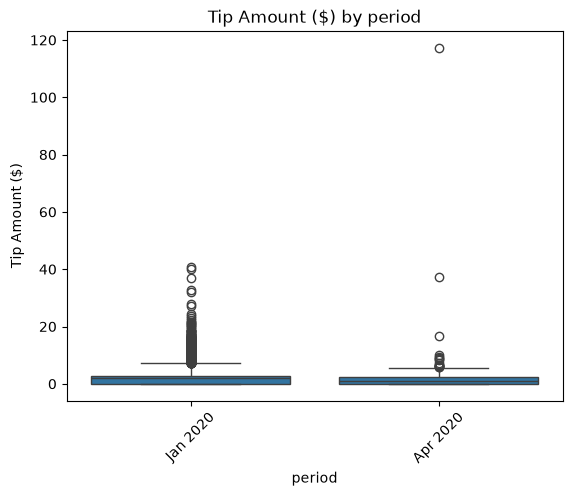

In [31]:
LOG.info("------- Creating another chart -------")

# plt.figure() opens a fresh blank canvas for the next chart

# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()
LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to the group column --------------------")
LOG.info(f"------   Set y to {BOX_Y_LABEL} ----------------------")

# Box plot to compare distribution across species
box_plt: Axes = sns.boxplot(
    data=df_clean,
    x=GROUP_COL,
    y=BOX_Y_COL,
)

# Set readable labels and title for the box plot
box_plt.set_xlabel(GROUP_COL)
box_plt.set_ylabel(BOX_Y_LABEL)
box_plt.set_title(f"{BOX_Y_LABEL} by {GROUP_COL}")

# Rotate the x-axis labels if there are many groups or long names
box_plt.tick_params(axis="x", labelrotation=45)

# Save the figure to docs/images
box_plt.figure.savefig("../docs/images/Figure_7.png", dpi=150, bbox_inches="tight")

LOG.info("Saved box plot to docs/images/Figure_7.png")

plt.show()

# Interpretation

Despite the dramatic drop in trip volume during April 2020, tip amounts followed a similar overall distribution to January, with most tips remaining small (under $5). However, April included one striking outlier — a roughly $116 tip — far exceeding any single tip recorded in the much larger January sample.

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [32]:
# Section 9

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column (e.g. species names)
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them alphabetically so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("EDA workflow complete")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-19 17:14:16 | INFO | P06-NB | ========================
2026-06-19 17:14:16 | INFO | P06-NB | SUMMARY
2026-06-19 17:14:16 | INFO | P06-NB | ========================
2026-06-19 17:14:16 | INFO | P06-NB | Dataset: yellow_taxi_2020_jan11_apr11_raw
2026-06-19 17:14:16 | INFO | P06-NB | Original rows: 15000
2026-06-19 17:14:16 | INFO | P06-NB | Clean rows:    14658
2026-06-19 17:14:16 | INFO | P06-NB | Groups found in period: ['Apr 2020', 'Jan 2020']
2026-06-19 17:14:16 | INFO | P06-NB | EDA workflow complete
2026-06-19 17:14:16 | INFO | P06-NB | ========================
2026-06-19 17:14:16 | INFO | P06-NB | Executed successfully!
2026-06-19 17:14:16 | INFO | P06-NB | ========================


## Summary
Loaded yellow_taxi_2020_jan11_apr11_raw (225,015 rows), sampled to 15,000, cleaned to 14,658
Grouped by period: Jan 2020 vs. Apr 2020
Reviewed statistics and correlations across trip_distance, fare_amount, passenger_count, tip_amount
Plotted Trip Distance vs. Fare Amount and Tip Amount by Period

## Custom Project
Used a new dataset (NYC Yellow Taxi Trips, Jan 11 and Apr 11, 2020) and sampled down to 15,000 rows
Created a period column to group by month
Saved Figure_5.png (heatmap), Figure_6.png (scatter plot), Figure_7.png (box plot)

## Findings
Ridership dropped ~96.5% from Jan to Apr (14,163 vs. 495 clean trips)
trip_distance and fare_amount correlate strongly (0.87); fare_amount and tip_amount moderately (0.62)
passenger_count showed little relationship to other variables
One ~110-mile, $578.50 trip on April 11 stands out as a major outlier
April had far fewer trips but one notable ~$116 tip outlier

## Next Steps
Address negative fare values
Investigate the outlier trips
Compare additional dates across the lockdown period
Try payment_type as an alternative grouping variable


## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 
